## Mental-Health Text Classification
### 1. Introduction
This project involves multi-class text classification of personal text data into 7 mental health categories (Normal, Depression, Suicidal, Anxiety, Bipolar, Stress, Personality Disorder).

**Approach overview** - two models:
- TF-IDF + logistic regression: a fast, interpretable baseline.
- Fine-tuned DistilBERT: a lightweight transformer that captures contextual and semantic nuances missed by bag-of-words approaches.

Ensured no data leakage in the pipeline (deduplicate before data splitting).

**Macro-F1** is used as the primary metric due to class imbalance.

### 2. Data understanding and quality control
#### 2.1 Class imbalance analysis

In [7]:
# Load data, and print summary statistics.
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# This notebook lives in mentalhealth/notebooks/; ROOT is the mentalhealth/ folder.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import load_raw, clean, get_splits, LABELS

OUT = ROOT / "outputs"; FIG = OUT / "figures"
raw = load_raw()

# class imbalance — raw dataset (before cleaning)
counts = raw["status"].value_counts().reindex(LABELS)
dist = pd.DataFrame({
    "count": counts,
    "percent": (counts / len(raw) * 100).round(1),
})
ratio = counts.max() / counts.min()
print(f"Class distribution (raw dataset, n = {len(raw):,}) — imbalance ratio {ratio:.1f} : 1")
print(dist.to_string())

Class distribution (raw dataset, n = 53,043) — imbalance ratio 13.6 : 1
                      count  percent
status                              
Normal                16351     30.8
Depression            15404     29.0
Suicidal              10653     20.1
Anxiety                3888      7.3
Bipolar                2877      5.4
Stress                 2669      5.0
Personality disorder   1201      2.3


### 2.2 Data cleaning
**Dropped**: Removed null statements, texts with conflicting labels, and duplicates.

**Still remain**: some non-English, non-ASCII, and mojibake texts. Filtering these would reduce small classes and worsen class imbalance, so they are kept for the baseline; stricter filtering is future work.

In [8]:
# data cleaning accounting table
df, accounting, stats = clean(raw)
acc = pd.DataFrame(accounting, columns=["step", "rows_remaining"])
acc["delta"] = acc["rows_remaining"].diff().fillna(0).astype(int)
display(acc)

,step,rows_remaining,delta
0,raw,53043,0
1,drop null statements,52681,-362
2,drop empty after normalise,52681,0
3,drop conflicting-label texts,52619,-62
4,dedup duplicate texts,51022,-1597


#### 2.3 Data preprocessing summary

Data cleaning (order matters): 
- Drop index 
- Remove nulls and empty texts
- Normalise whitespace
- Remove conflicting-label texts 
- Deduplicate
- Split dataset into train/val/test

Deduplicate before splitting to avoid data leakage 
- After cleaning: 53,043 → 51,022 rows
- 0.8:0.1:0.1 split = 40,817 / 5,102 / 5,103

In [9]:
# print splits summary
train, val, test = get_splits()
print(f"raw rows: {len(raw):,}   clean rows: {len(df):,}")
print(f"splits -> train {len(train):,} | val {len(val):,} | test {len(test):,}")

raw rows: 53,043   clean rows: 51,022
splits -> train 40,817 | val 5,102 | test 5,103


### 3. Modeling
TF-IDF + Logistic Regression
- Straightforward baseline using 1–2 gram TF-IDF features
- Fast to train and run, interpretable (insight into important words)
- Strong benchmark for comparison

Fine-tuned DistilBERT
- Lightweight encoder-only transformer
- Captures contextual information, word order, and semantic nuances.
- More powerful at the cost of additional compute

Models trained via `python -m src.train_eval_LR` and `python -m src.train_eval_transformer`; this notebook loads the saved results.

### 4. Results and evaluation
DistilBERT improves the Macro-F1 score by ~0.10, indicating meaningful linguistic signal beyond bag-of-words features.

The gap between Accuracy and Macro-F1 highlights the impact of class imbalance.

**Confusion Matrix Insights** 
- Both models perform strongly on the "Normal" class.
- Notable confusion between **Depression** and **Suicidal** classes (overlapping language).
- DistilBERT improves recall for all classes (diagonal values = per-class recall).

In [10]:
# Model comparison table: accuracy and macro-F1 for two models
metrics = json.loads((OUT / "metrics.json").read_text())
comp = pd.DataFrame(metrics["comparison_full"]).set_index("model")
tp = OUT / "transformer_metrics.json"
if tp.exists():
    t = json.loads(tp.read_text())
    comp.loc["distilbert"] = {"accuracy": t["test_accuracy"], "macro_f1": t["test_macro_f1"]}
comp = comp.rename(columns={"accuracy": "Accuracy", "macro_f1": "Macro-F1"})
display(comp.round(3))

,Accuracy,Macro-F1
model,,
tfidf_logistic_regression,0.756,0.706
distilbert,0.826,0.804


Row-normalised confusion matrices — left TF-IDF+Logistic regression, right DistilBERT; diagonal = recall. Note the **Depression - Suicidal** block.

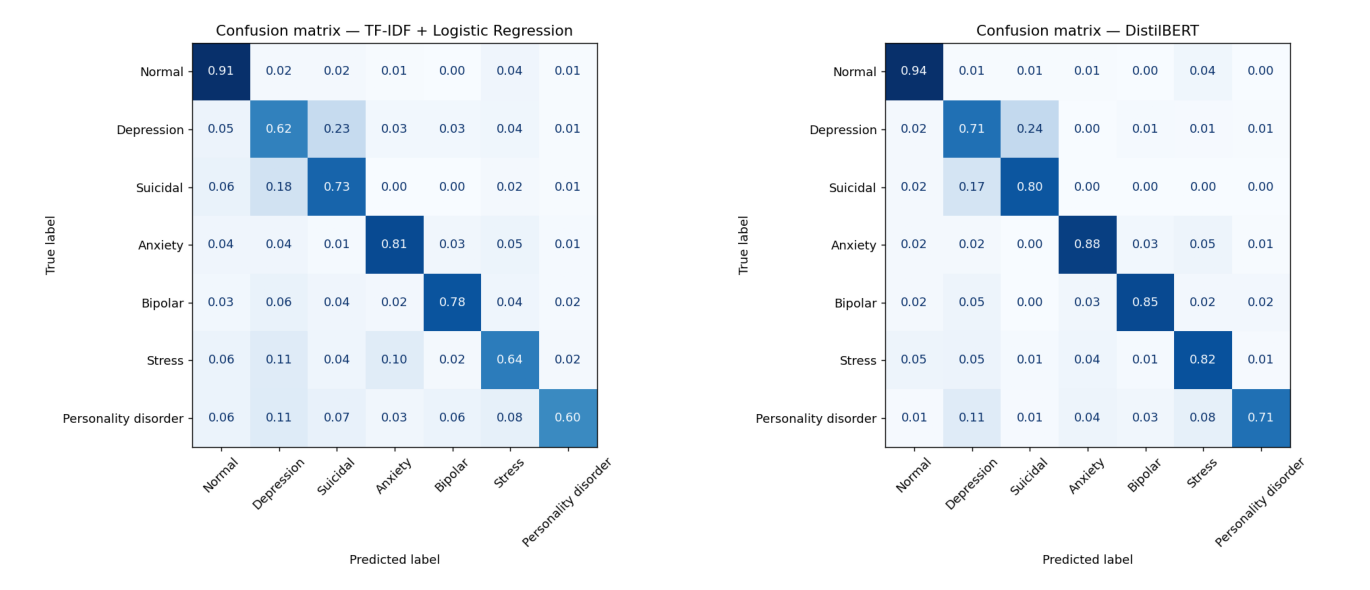

In [13]:
# plot the confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, ["confusion_full.png", "confusion_distilbert.png"]):
    ax.imshow(plt.imread(FIG / name))
    ax.axis("off")
plt.tight_layout()
plt.show()


Per-class precision / recall / F1 for both models, plus the baseline's top TF-IDF features per class.

In [12]:
# Per-class performance: both models side by side.
tfm = json.loads((OUT / "transformer_metrics.json").read_text())["per_class"]

def _per_class(report, model):
    df = pd.DataFrame({c: report[c] for c in LABELS}).T[["precision", "recall", "f1-score"]]
    df.columns = pd.MultiIndex.from_product([[model], df.columns])
    return df.round(3)

per_class = pd.concat([_per_class(metrics["per_class_full"], "TF-IDF+LogReg"),
                       _per_class(tfm, "DistilBERT")], axis=1)
per_class.insert(0, ("", "support"), [int(metrics["per_class_full"][c]["support"]) for c in LABELS])
print("Per-class performance: TF-IDF+LogReg vs DistilBERT")
display(per_class)

# the most-weighted TF-IDF features per class (for interpretability)
tf = pd.DataFrame({c: metrics["top_features"][c][:5] for c in LABELS})
print("Top TF-IDF features per class:")
display(tf)

Per-class performance: TF-IDF+LogReg vs DistilBERT


TF-IDF+LogReg                 DistilBERT         \
                     support     precision recall f1-score  precision recall   
Normal                  1602         0.887  0.909    0.898      0.956  0.942   
Depression              1508         0.768  0.622    0.687      0.823  0.708   
Suicidal                1064         0.658  0.727    0.691      0.690  0.805   
Anxiety                  361         0.756  0.814    0.784      0.891  0.884   
Bipolar                  250         0.737  0.784    0.760      0.841  0.848   
Stress                   229         0.467  0.642    0.540      0.642  0.821   
Personality disorder      89         0.564  0.596    0.579      0.741  0.708   

                               
                     f1-score  
Normal                  0.949  
Depression              0.761  
Suicidal                0.743  
Anxiety                 0.887  
Bipolar                 0.845  
Stress                  0.720  
Personality disorder    0.724

Top TF-IDF features per class:


,Normal,Depression,Suicidal,Anxiety,Bipolar,Stress,Personality disorder
0,wa,depression,suicide,anxiety,bipolar,stress,avpd
1,url,wa,kill,restless,manic,stressed,avoidant
2,ðy,depressed,suicidal,anxious,meds,ptsd,don
3,twitter,ha,die,worried,episode,tl dr,people
4,quot,doe,anymore,nervous,mania,don,social


### 5. Limitations and Future Improvements
#### Data Perspective
- **Label noise & overlapping categories**: 
  - Conflicting labels and overlap (Depression/Stress/Suicidal) limit performance.
  - Improvement: Stricter quality filters and relabeling.
  
- **Length & platform bias**: 
  - Models can partially rely on text length or platform artifacts.  
  - Improvement: Use length-controlled evaluation and debiasing techniques. Extend the dataset with data augmentation and more diverse sources.

- **Single-label assumption**: 
  - Real mental health problems often involve multiple overlapping conditions.
  - Improvement: Reformulate as a multi-label classification.

---

#### Modeling Perspective
- **Domain understanding**: 
  - Standard models may miss mental-health-specific nuances.  
  - Improvement: Advanced features (Word2Vec embeddings and sentiment features) or domain-adapted models (MentalBERT).

- **Safety-critical errors**: 
  - Missing "Suicidal" cases has high cost.
  - Improvement: Prioritize recall for "Suicidal" class.

- **Single-stage classification**: 
  - Treating all categories equally in one step may not be optimal.
  - Improvement: Two-stage pipeline (Normal vs. Clinical, then clinical Subtype).
